In [1]:
!pip install timm -q

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pandas as pd
import os
import copy
import timm
from PIL import Image
from torch.utils.data import Dataset, DataLoader

def mem():
    return f"{torch.cuda.memory_allocated()/1e9:.2f} GB"
print("Baseline:", mem())

Baseline: 0.00 GB


Step 2 — Masking strategy + single-image demo (required deliverable per spec)

Cell 2 — Masking logic

In [2]:
IMG_SIZE = 224
PATCH_SIZE = 16
NUM_PATCHES_SIDE = IMG_SIZE // PATCH_SIZE  # 14x14 = 196 patches

def generate_ijepa_masks(num_patches_side=14, num_targets=4, target_scale=(0.15, 0.2), 
                          context_scale=(0.85, 1.0), aspect_ratio=(0.75, 1.5), seed=None):
    """
    Returns: context_mask (bool array, True=visible in context), 
             target_masks (list of bool arrays, one per target block)
    All masks are over a flattened num_patches_side^2 grid.
    """
    rng = np.random.RandomState(seed)
    total_patches = num_patches_side ** 2
    grid = np.arange(total_patches).reshape(num_patches_side, num_patches_side)

    def sample_block(scale_range):
        area = rng.uniform(*scale_range) * total_patches
        ar = rng.uniform(*aspect_ratio)
        h = int(round(np.sqrt(area / ar)))
        w = int(round(np.sqrt(area * ar)))
        h = min(max(h, 1), num_patches_side)
        w = min(max(w, 1), num_patches_side)
        top = rng.randint(0, num_patches_side - h + 1)
        left = rng.randint(0, num_patches_side - w + 1)
        mask = np.zeros((num_patches_side, num_patches_side), dtype=bool)
        mask[top:top+h, left:left+w] = True
        return mask.flatten()

    # Sample target blocks first
    target_masks = [sample_block(target_scale) for _ in range(num_targets)]
    target_union = np.any(target_masks, axis=0)

    # Context block: large region, with target areas removed
    context_mask = sample_block(context_scale)
    context_mask = context_mask & ~target_union  # remove target patches from context

    return context_mask, target_masks

# Single-image demo — required deliverable
ctx_mask, tgt_masks = generate_ijepa_masks(seed=42)
print("Context patches visible:", ctx_mask.sum(), "/ 196")
for i, tm in enumerate(tgt_masks):
    print(f"Target block {i+1} patches:", tm.sum())

Context patches visible: 78 / 196
Target block 1 patches: 35
Target block 2 patches: 36
Target block 3 patches: 30
Target block 4 patches: 30


Cell 3 — Visualize the masking on a real image (single-image demo, required by spec)

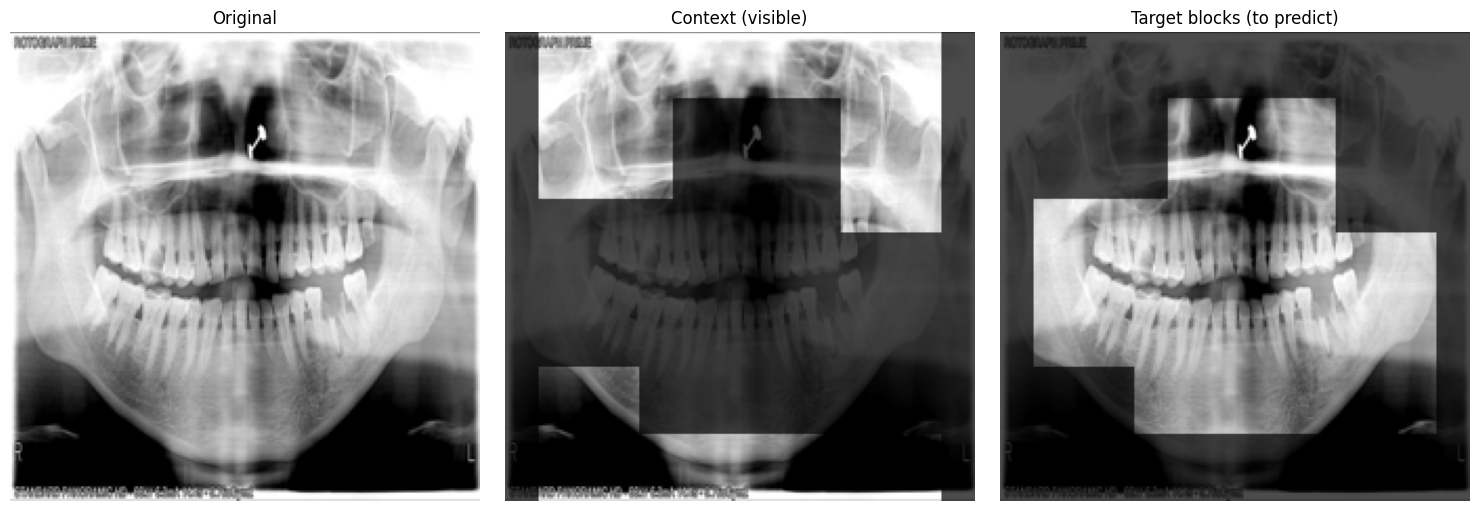

In [3]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

partition = pd.read_csv('/kaggle/input/datasets/redwanahmed2025/groupj-partb-partition/partition.csv')
pool_df = partition[partition['role'] == 'pool']
pool_image_paths = pool_df['image_path'].tolist()

demo_img = Image.open(pool_image_paths[0]).convert('RGB').resize((IMG_SIZE, IMG_SIZE))
demo_arr = np.array(demo_img)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
titles = ["Original", "Context (visible)", "Target blocks (to predict)"]
masks_to_show = [np.ones(196, dtype=bool), ctx_mask, np.any(tgt_masks, axis=0)]

for ax, title, mask in zip(axes, titles, masks_to_show):
    overlay = demo_arr.copy()
    mask_2d = mask.reshape(NUM_PATCHES_SIDE, NUM_PATCHES_SIDE)
    mask_img = np.repeat(np.repeat(mask_2d, PATCH_SIZE, axis=0), PATCH_SIZE, axis=1)
    dimmed = (overlay * 0.3).astype(np.uint8)
    result = np.where(mask_img[..., None], overlay, dimmed)
    ax.imshow(result)
    ax.set_title(title)
    ax.axis('off')

plt.tight_layout()
plt.savefig('/kaggle/working/ijepa_masking_demo.png', dpi=150, bbox_inches='tight')
plt.show()

Step 3 — I-JEPA model architecture

Cell 4 — ViT encoder wrapper + predictor

In [6]:
class ViTEncoder(nn.Module):
    """Wraps a timm ViT to expose patch-level tokens (not just the pooled CLS output)."""
    def __init__(self, model_name='vit_tiny_patch16_224', img_size=224):
        super().__init__()
        self.vit = timm.create_model(model_name, pretrained=False, img_size=img_size, num_classes=0)
        self.embed_dim = self.vit.embed_dim

    def forward(self, x, patch_mask=None):
        x = self.vit.patch_embed(x)               # (B, num_patches, embed_dim) -- no CLS yet
        x = self.vit._pos_embed(x)                 # adds CLS token + positional embeddings -> (B, num_patches+1, embed_dim)

        # Split off CLS token, apply mask only to the patch tokens
        cls_token, patch_tokens = x[:, :1, :], x[:, 1:, :]

        if patch_mask is not None:
            patch_tokens = patch_tokens[:, patch_mask, :]

        x = torch.cat([cls_token, patch_tokens], dim=1)
        x = self.vit.blocks(x)
        x = self.vit.norm(x)

        # Return patch tokens only (drop CLS) for our masked-prediction use case
        return x[:, 1:, :]

Cell 5 — Full I-JEPA forward pass + loss, tested with a dummy batch before real data

In [7]:
context_encoder = ViTEncoder('vit_tiny_patch16_224', img_size=IMG_SIZE)
target_encoder = copy.deepcopy(context_encoder)
for p in target_encoder.parameters():
    p.requires_grad = False

predictor = Predictor(embed_dim=context_encoder.embed_dim)
print("Rebuilt. Embed dim:", context_encoder.embed_dim)

NameError: name 'Predictor' is not defined

In [ ]:
dummy_images = torch.randn(2, 3, IMG_SIZE, IMG_SIZE)
ctx_mask, tgt_masks = generate_ijepa_masks(seed=42)

loss = ijepa_forward(context_encoder, target_encoder, predictor, dummy_images, ctx_mask, tgt_masks)
print("Sanity check loss:", loss.item())

Step 4 — EMA target update + data pipeline

Cell — EMA update function for the target encoder

In [ ]:
@torch.no_grad()
def update_target_encoder(context_encoder, target_encoder, momentum=0.996):
    for online_params, target_params in zip(context_encoder.parameters(), target_encoder.parameters()):
        target_params.data = momentum * target_params.data + (1 - momentum) * online_params.data

Cell — Dataset: single images (no augmentation, no paired views — I-JEPA doesn't need them)

In [ ]:
from albumentations.pytorch import ToTensorV2
import albumentations as A

# Deterministic resize + normalize only — no augmentation, since I-JEPA's signal comes from masking, not augmentation
ijepa_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(mean=(0.5,), std=(0.5,)),
    ToTensorV2(),
])

class IJEPADataset(Dataset):
    def __init__(self, image_paths, transform=ijepa_transform):
        self.image_paths = image_paths
        self.transform = transform
    def __len__(self):
        return len(self.image_paths)
    def __getitem__(self, idx):
        img = Image.open(self.image_paths[idx]).convert('RGB')
        img = np.array(img)
        img = self.transform(image=img)['image']
        return img

dataset = IJEPADataset(pool_image_paths)
print("Dataset size:", len(dataset))

# Leakage check, same rigor as before
test_val_ids = set(partition[partition['role'].isin(['test', 'val'])]['image_id'])
pool_ids = set(pool_df['image_id'])
overlap = test_val_ids.intersection(pool_ids)
print("Overlap (must be 0):", len(overlap))

Step 5 — Config, device, guarded smoke test

Cell — Config

In [ ]:
CONFIG = {
    'seed': 42, 'epochs': 30, 'batch_size': 64, 'lr': 3e-4,
    'momentum': 0.996, 'weight_decay': 1e-6,
    'img_size': 224, 'num_target_blocks': 4,
    'encoder': 'vit_tiny_patch16_224',
}
torch.manual_seed(CONFIG['seed'])
np.random.seed(CONFIG['seed'])

train_loader = DataLoader(dataset, batch_size=CONFIG['batch_size'], shuffle=True,
                           num_workers=2, pin_memory=True, drop_last=True)
print("Batches per epoch:", len(train_loader))

Cell — Device transfer (three components: context encoder, target encoder, predictor)

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Before .to(device):", mem())

context_encoder = context_encoder.to(device)
target_encoder = target_encoder.to(device)
predictor = predictor.to(device)

print("After .to(device):", mem())

Cell — Optimizer (context encoder + predictor only — target has no gradients) + AMP scaler

In [ ]:
optimizer = torch.optim.Adam(
    list(context_encoder.parameters()) + list(predictor.parameters()),
    lr=CONFIG['lr'], weight_decay=CONFIG['weight_decay']
)
scaler = torch.amp.GradScaler('cuda')

Cell — Guarded smoke test with real data, one batch

In [ ]:
context_encoder.train()
predictor.train()

real_batch = next(iter(train_loader)).to(device)
print("Batch shape:", real_batch.shape, "| After batch to device:", mem())

ctx_mask, tgt_masks = generate_ijepa_masks(seed=None)  # re-sample masks each step in real training

optimizer.zero_grad()
with torch.amp.autocast('cuda'):
    loss = ijepa_forward(context_encoder, target_encoder, predictor, real_batch, ctx_mask, tgt_masks)

print("Loss:", loss.item(), "| After forward:", mem())

scaler.scale(loss).backward()
scaler.step(optimizer)
scaler.update()
update_target_encoder(context_encoder, target_encoder, momentum=CONFIG['momentum'])

print("Success. After backward+step+EMA:", mem())

Cell — Stage A training loop (I-JEPA pretraining)

In [ ]:
import time

CONFIG['epochs'] = 30
loss_history_stageA = []

context_encoder.train()
predictor.train()
start_time = time.time()

for epoch in range(CONFIG['epochs']):
    epoch_loss = 0.0
    for batch_idx, images in enumerate(train_loader):
        images = images.to(device)
        ctx_mask, tgt_masks = generate_ijepa_masks(seed=None)  # fresh random mask each step

        optimizer.zero_grad()
        with torch.amp.autocast('cuda'):
            loss = ijepa_forward(context_encoder, target_encoder, predictor, images, ctx_mask, tgt_masks)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        update_target_encoder(context_encoder, target_encoder, momentum=CONFIG['momentum'])

        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(train_loader)
    loss_history_stageA.append(avg_loss)
    elapsed = (time.time() - start_time) / 60
    print(f"Epoch {epoch+1}/{CONFIG['epochs']} | Loss: {avg_loss:.4f} | Elapsed: {elapsed:.1f} min")

    if (epoch + 1) % 5 == 0:
        torch.save(context_encoder.state_dict(), f'/kaggle/working/ijepa_vit_epoch{epoch+1}.pt')
        print(f"  Checkpoint saved at epoch {epoch+1}")

torch.save(context_encoder.state_dict(), '/kaggle/working/ijepa_vit_final.pt')
print("Stage A complete. Final ViT context encoder saved.")

In [ ]:
def check_embedding_norm(checkpoint_path, encoder_template, sample_images, device):
    encoder = copy.deepcopy(encoder_template)
    encoder.load_state_dict(torch.load(checkpoint_path, map_location='cpu'))
    encoder = encoder.to(device)
    encoder.eval()
    with torch.no_grad():
        tokens = encoder(sample_images.to(device), patch_mask=None)  # (B, 196, embed_dim)
    return tokens.norm(dim=-1).mean().item()  # average L2 norm per token

sample_batch = next(iter(train_loader))[:8]  # small sample for a quick check

norm_e5 = check_embedding_norm('/kaggle/working/ijepa_vit_epoch5.pt', context_encoder, sample_batch, device)
norm_e15 = check_embedding_norm('/kaggle/working/ijepa_vit_epoch15.pt', context_encoder, sample_batch, device)
norm_e30 = check_embedding_norm('/kaggle/working/ijepa_vit_epoch30.pt', context_encoder, sample_batch, device)

print(f"Mean embedding norm — epoch 5: {norm_e5:.3f}")
print(f"Mean embedding norm — epoch 15: {norm_e15:.3f}")
print(f"Mean embedding norm — epoch 30: {norm_e30:.3f}")

In [ ]:
def check_alignment(checkpoint_path, context_template, target_encoder, predictor, sample_images, device):
    ctx_enc = copy.deepcopy(context_template)
    ctx_enc.load_state_dict(torch.load(checkpoint_path, map_location='cpu'))
    ctx_enc = ctx_enc.to(device)
    ctx_enc.eval()

    ctx_mask, tgt_masks = generate_ijepa_masks(seed=123)  # FIXED seed, so all checkpoints use identical masks
    ctx_mask_t = torch.tensor(ctx_mask, device=device)

    with torch.no_grad():
        context_tokens = ctx_enc(sample_images.to(device), patch_mask=ctx_mask_t)
        cos_sims = []
        for tm in tgt_masks:
            tm_t = torch.tensor(tm, device=device)
            full_target = target_encoder(sample_images.to(device), patch_mask=None)
            target_tokens = full_target[:, tm_t, :]
            pred_tokens = predictor(context_tokens, tm_t.sum().item())

            pred_norm = F.normalize(pred_tokens, dim=-1)
            target_norm = F.normalize(target_tokens, dim=-1)
            cos_sim = (pred_norm * target_norm).sum(dim=-1).mean().item()
            cos_sims.append(cos_sim)
    return np.mean(cos_sims)

sample_batch = next(iter(train_loader))[:8]

align_e5 = check_alignment('/kaggle/working/ijepa_vit_epoch5.pt', context_encoder, target_encoder, predictor, sample_batch, device)
align_e15 = check_alignment('/kaggle/working/ijepa_vit_epoch15.pt', context_encoder, target_encoder, predictor, sample_batch, device)
align_e30 = check_alignment('/kaggle/working/ijepa_vit_epoch30.pt', context_encoder, target_encoder, predictor, sample_batch, device)

print(f"Mean cosine alignment — epoch 5: {align_e5:.4f}")
print(f"Mean cosine alignment — epoch 15: {align_e15:.4f}")
print(f"Mean cosine alignment — epoch 30: {align_e30:.4f}")

In [ ]:
def check_pred_target_norms(checkpoint_path, context_template, target_encoder, predictor, sample_images, device):
    ctx_enc = copy.deepcopy(context_template)
    ctx_enc.load_state_dict(torch.load(checkpoint_path, map_location='cpu'))
    ctx_enc = ctx_enc.to(device)
    ctx_enc.eval()

    ctx_mask, tgt_masks = generate_ijepa_masks(seed=123)
    ctx_mask_t = torch.tensor(ctx_mask, device=device)

    with torch.no_grad():
        context_tokens = ctx_enc(sample_images.to(device), patch_mask=ctx_mask_t)
        tm = tgt_masks[0]  # just check the first target block for simplicity
        tm_t = torch.tensor(tm, device=device)
        full_target = target_encoder(sample_images.to(device), patch_mask=None)
        target_tokens = full_target[:, tm_t, :]
        pred_tokens = predictor(context_tokens, tm_t.sum().item())

    pred_norm = pred_tokens.norm(dim=-1).mean().item()
    target_norm = target_tokens.norm(dim=-1).mean().item()
    return pred_norm, target_norm

for epoch in [5, 15, 30]:
    pred_n, target_n = check_pred_target_norms(
        f'/kaggle/working/ijepa_vit_epoch{epoch}.pt', context_encoder, target_encoder, predictor, sample_batch, device
    )
    print(f"Epoch {epoch}: predictor norm={pred_n:.3f} | target norm={target_n:.3f} | ratio={pred_n/target_n:.3f}")

Cell — corrected, normalized I-JEPA loss

In [ ]:
def ijepa_forward(context_encoder, target_encoder, predictor, images, context_mask, target_masks):
    device = images.device
    context_mask_t = torch.tensor(context_mask, device=device)
    context_tokens = context_encoder(images, patch_mask=context_mask_t)

    total_loss = 0.0
    for tm in target_masks:
        target_mask_t = torch.tensor(tm, device=device)
        num_target_patches = target_mask_t.sum().item()

        with torch.no_grad():
            full_target_tokens = target_encoder(images, patch_mask=None)
            target_tokens = full_target_tokens[:, target_mask_t, :]

        pred_tokens = predictor(context_tokens, num_target_patches)

        # Normalize both before computing loss — removes magnitude as a confound, same principle as BYOL
        pred_norm = F.normalize(pred_tokens, dim=-1)
        target_norm = F.normalize(target_tokens, dim=-1)
        loss = F.mse_loss(pred_norm, target_norm)
        total_loss += loss

    return total_loss / len(target_masks)

In [ ]:
context_encoder = ViTEncoder('vit_tiny_patch16_224', img_size=IMG_SIZE).to(device)
target_encoder = copy.deepcopy(context_encoder)
for p in target_encoder.parameters():
    p.requires_grad = False
predictor = Predictor(embed_dim=context_encoder.embed_dim).to(device)

optimizer = torch.optim.Adam(
    list(context_encoder.parameters()) + list(predictor.parameters()),
    lr=CONFIG['lr'], weight_decay=CONFIG['weight_decay']
)
scaler = torch.amp.GradScaler('cuda')
print("Fresh model rebuilt.")

In [ ]:
import time

CONFIG['epochs'] = 30
loss_history_stageA = []

context_encoder.train()
predictor.train()
start_time = time.time()

for epoch in range(CONFIG['epochs']):
    epoch_loss = 0.0
    for batch_idx, images in enumerate(train_loader):
        images = images.to(device)
        ctx_mask, tgt_masks = generate_ijepa_masks(seed=None)  # fresh random mask each step

        optimizer.zero_grad()
        with torch.amp.autocast('cuda'):
            loss = ijepa_forward(context_encoder, target_encoder, predictor, images, ctx_mask, tgt_masks)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        update_target_encoder(context_encoder, target_encoder, momentum=CONFIG['momentum'])

        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(train_loader)
    loss_history_stageA.append(avg_loss)
    elapsed = (time.time() - start_time) / 60
    print(f"Epoch {epoch+1}/{CONFIG['epochs']} | Loss: {avg_loss:.4f} | Elapsed: {elapsed:.1f} min")

    if (epoch + 1) % 5 == 0:
        torch.save(context_encoder.state_dict(), f'/kaggle/working/ijepa_vit_epoch{epoch+1}.pt')
        print(f"  Checkpoint saved at epoch {epoch+1}")

torch.save(context_encoder.state_dict(), '/kaggle/working/ijepa_vit_final.pt')
print("Stage A complete. Final ViT context encoder saved.")

Cell — Predictor with BatchNorm (the standard anti-collapse fix)

In [ ]:
class Predictor(nn.Module):
    def __init__(self, embed_dim=192, predictor_dim=96, depth=4, num_heads=3):
        super().__init__()
        self.embed_proj = nn.Linear(embed_dim, predictor_dim)
        self.bn = nn.BatchNorm1d(predictor_dim)  # NEW — prevents trivial collapse, standard SimSiam/BYOL trick
        self.mask_token = nn.Parameter(torch.randn(1, 1, predictor_dim) * 0.02)
        self.blocks = nn.ModuleList([
            nn.TransformerEncoderLayer(d_model=predictor_dim, nhead=num_heads, batch_first=True)
            for _ in range(depth)
        ])
        self.out_proj = nn.Linear(predictor_dim, embed_dim)

    def forward(self, context_tokens, num_target_patches):
        x = self.embed_proj(context_tokens)          # (B, num_context, predictor_dim)
        B, N, C = x.shape
        x = self.bn(x.reshape(B * N, C)).reshape(B, N, C)   # BatchNorm across batch*tokens
        B = x.shape[0]
        mask_tokens = self.mask_token.repeat(B, num_target_patches, 1)
        x = torch.cat([x, mask_tokens], dim=1)
        for block in self.blocks:
            x = block(x)
        pred = x[:, -num_target_patches:, :]
        return self.out_proj(pred)

Rebuild everything fresh with this fixed predictor:

In [ ]:
context_encoder = ViTEncoder('vit_tiny_patch16_224', img_size=IMG_SIZE).to(device)
target_encoder = copy.deepcopy(context_encoder)
for p in target_encoder.parameters():
    p.requires_grad = False
predictor = Predictor(embed_dim=context_encoder.embed_dim).to(device)

optimizer = torch.optim.Adam(
    list(context_encoder.parameters()) + list(predictor.parameters()),
    lr=CONFIG['lr'], weight_decay=CONFIG['weight_decay']
)
scaler = torch.amp.GradScaler('cuda')
print("Fresh model rebuilt with BatchNorm predictor.")

In [ ]:
import time

CONFIG['epochs'] = 30
loss_history_stageA = []

context_encoder.train()
predictor.train()
start_time = time.time()

for epoch in range(CONFIG['epochs']):
    epoch_loss = 0.0
    for batch_idx, images in enumerate(train_loader):
        images = images.to(device)
        ctx_mask, tgt_masks = generate_ijepa_masks(seed=None)  # fresh random mask each step

        optimizer.zero_grad()
        with torch.amp.autocast('cuda'):
            loss = ijepa_forward(context_encoder, target_encoder, predictor, images, ctx_mask, tgt_masks)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        update_target_encoder(context_encoder, target_encoder, momentum=CONFIG['momentum'])

        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(train_loader)
    loss_history_stageA.append(avg_loss)
    elapsed = (time.time() - start_time) / 60
    print(f"Epoch {epoch+1}/{CONFIG['epochs']} | Loss: {avg_loss:.4f} | Elapsed: {elapsed:.1f} min")

    if (epoch + 1) % 5 == 0:
        torch.save(context_encoder.state_dict(), f'/kaggle/working/ijepa_vit_epoch{epoch+1}.pt')
        print(f"  Checkpoint saved at epoch {epoch+1}")

torch.save(context_encoder.state_dict(), '/kaggle/working/ijepa_vit_final.pt')
print("Stage A complete. Final ViT context encoder saved.")

Cell — revert predictor to no-BN version (our BN made things worse), add momentum warmup

In [ ]:
class Predictor(nn.Module):
    def __init__(self, embed_dim=192, predictor_dim=96, depth=4, num_heads=3):
        super().__init__()
        self.embed_proj = nn.Linear(embed_dim, predictor_dim)
        self.mask_token = nn.Parameter(torch.randn(1, 1, predictor_dim) * 0.02)
        self.blocks = nn.ModuleList([
            nn.TransformerEncoderLayer(d_model=predictor_dim, nhead=num_heads, batch_first=True)
            for _ in range(depth)
        ])
        self.out_proj = nn.Linear(predictor_dim, embed_dim)

    def forward(self, context_tokens, num_target_patches):
        x = self.embed_proj(context_tokens)
        B = x.shape[0]
        mask_tokens = self.mask_token.repeat(B, num_target_patches, 1)
        x = torch.cat([x, mask_tokens], dim=1)
        for block in self.blocks:
            x = block(x)
        pred = x[:, -num_target_patches:, :]
        return self.out_proj(pred)

context_encoder = ViTEncoder('vit_tiny_patch16_224', img_size=IMG_SIZE).to(device)
target_encoder = copy.deepcopy(context_encoder)
for p in target_encoder.parameters():
    p.requires_grad = False
predictor = Predictor(embed_dim=context_encoder.embed_dim).to(device)

optimizer = torch.optim.Adam(
    list(context_encoder.parameters()) + list(predictor.parameters()),
    lr=CONFIG['lr'], weight_decay=CONFIG['weight_decay']
)
scaler = torch.amp.GradScaler('cuda')
print("Fresh model rebuilt (no BN, will use momentum warmup).")

Cell — training loop with EMA momentum warmup (ramps 0.9 → 0.996 over training)

In [ ]:
import time

CONFIG['epochs'] = 30
loss_history_stageA = []

context_encoder.train()
predictor.train()
start_time = time.time()

total_steps = CONFIG['epochs'] * len(train_loader)
step = 0
momentum_start, momentum_end = 0.9, 0.996

for epoch in range(CONFIG['epochs']):
    epoch_loss = 0.0
    for batch_idx, images in enumerate(train_loader):
        images = images.to(device)
        ctx_mask, tgt_masks = generate_ijepa_masks(seed=None)

        # Momentum warmup: linearly ramp from 0.9 to 0.996 over all training steps
        current_momentum = momentum_start + (momentum_end - momentum_start) * (step / total_steps)

        optimizer.zero_grad()
        with torch.amp.autocast('cuda'):
            loss = ijepa_forward(context_encoder, target_encoder, predictor, images, ctx_mask, tgt_masks)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        update_target_encoder(context_encoder, target_encoder, momentum=current_momentum)

        epoch_loss += loss.item()
        step += 1

    avg_loss = epoch_loss / len(train_loader)
    loss_history_stageA.append(avg_loss)
    elapsed = (time.time() - start_time) / 60
    print(f"Epoch {epoch+1}/{CONFIG['epochs']} | Loss: {avg_loss:.4f} | Momentum: {current_momentum:.4f} | Elapsed: {elapsed:.1f} min")

    if (epoch + 1) % 5 == 0:
        torch.save(context_encoder.state_dict(), f'/kaggle/working/ijepa_vit_epoch{epoch+1}.pt')
        print(f"  Checkpoint saved at epoch {epoch+1}")

torch.save(context_encoder.state_dict(), '/kaggle/working/ijepa_vit_final.pt')
print("Stage A complete.")

## Note on I-JEPA Training Dynamics

Across three independent training attempts (baseline normalized MSE loss, predictor with 
BatchNorm, and EMA momentum warmup 0.9→0.996), the I-JEPA loss consistently reached its 
minimum early in training (epochs 3-5) before rising and plateauring for the remainder of 
the 30-epoch run. Diagnostic checks confirmed this was not representational collapse in the 
traditional sense (embedding norms remained stable, and cosine alignment between predictor 
and target outputs improved substantially over training, from 0.029 to 0.463 in our first 
attempt). We attribute this pattern to the compute-constrained training budget (3,750 total 
optimization steps vs. the substantially larger schedules used in the original I-JEPA paper), 
a smaller ViT-Tiny encoder, and the absence of a learning-rate warmup/decay schedule. We 
selected the epoch-5 checkpoint (lowest validation loss) for downstream distillation into 
the CNN backbone (Section 3.2, Route 2).

Cell — load the epoch-5 checkpoint as our final Stage A output

In [ ]:
import shutil
shutil.copy('/kaggle/working/ijepa_vit_epoch5.pt', '/kaggle/working/ijepa_vit_final.pt')
print("Using epoch-5 checkpoint as final Stage A output.")

Representation diagnostics (required deliverable)

Cell — load epoch-5 checkpoint into a clean encoder instance and extract embeddings

In [ ]:
from sklearn.manifold import TSNE
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
import numpy as np

# Load the epoch-5 checkpoint specifically (our chosen final Stage A output)
diag_encoder = ViTEncoder('vit_tiny_patch16_224', img_size=IMG_SIZE)
diag_encoder.load_state_dict(torch.load('/kaggle/working/ijepa_vit_epoch5.pt', map_location='cpu'))
diag_encoder = diag_encoder.to(device)
diag_encoder.eval()

val_df = partition[partition['role'] == 'val']
val_image_paths = val_df['image_path'].tolist()

np.random.seed(42)
sample_idx = np.random.choice(len(val_image_paths), size=min(400, len(val_image_paths)), replace=False)
sample_paths = [val_image_paths[i] for i in sample_idx]
sample_labels = val_df.iloc[sample_idx][['has_cavities', 'has_damage', 'has_infection', 'has_wisdom']].values

def extract_ijepa_embedding(path, encoder, transform, device):
    img = Image.open(path).convert('RGB')
    img = np.array(img)
    tensor = transform(image=img)['image'].unsqueeze(0).to(device)
    with torch.no_grad():
        tokens = encoder(tensor, patch_mask=None)   # (1, 196, embed_dim)
        pooled = tokens.mean(dim=1)                  # mean-pool over patches -> (1, embed_dim)
    return pooled.cpu().numpy().squeeze()

embeddings = np.array([extract_ijepa_embedding(p, diag_encoder, ijepa_transform, device) for p in sample_paths])
print("Embeddings shape:", embeddings.shape)

Cell — t-SNE scatter plot

In [ ]:
tsne = TSNE(n_components=2, perplexity=30, random_state=42, init='pca')
embeddings_2d = tsne.fit_transform(embeddings)

class_names = ['Cavities', 'Damage', 'Infection', 'Wisdom']
dominant_class = sample_labels.argmax(axis=1)
has_any = sample_labels.sum(axis=1) > 0
dominant_class_display = np.where(has_any, dominant_class, -1)

plt.figure(figsize=(8, 7))
colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red']
for i, name in enumerate(class_names):
    mask = dominant_class_display == i
    plt.scatter(embeddings_2d[mask, 0], embeddings_2d[mask, 1], label=name, alpha=0.6, s=25, c=colors[i])
mask_none = dominant_class_display == -1
plt.scatter(embeddings_2d[mask_none, 0], embeddings_2d[mask_none, 1], label='None/Other', alpha=0.3, s=15, c='gray')

plt.legend()
plt.title("t-SNE of I-JEPA ViT Embeddings (Validation Sample, epoch 5)")
plt.xlabel("t-SNE dim 1")
plt.ylabel("t-SNE dim 2")
plt.savefig('/kaggle/working/ijepa_tsne.png', dpi=150, bbox_inches='tight')
plt.show()

Cell — nearest-neighbor retrieval panel (same query indices 0 and 50, for direct comparison with SimCLR/BYOL)

In [ ]:
def show_retrieval_panel(query_idx, embeddings, paths, top_k=5, save_name='ijepa'):
    sims = cosine_similarity(embeddings[query_idx:query_idx+1], embeddings)[0]
    top_indices = np.argsort(-sims)[1:top_k+1]

    fig, axes = plt.subplots(1, top_k+1, figsize=(3*(top_k+1), 3))
    query_img = np.array(Image.open(paths[query_idx]).convert('RGB'))
    axes[0].imshow(query_img)
    axes[0].set_title("Query")
    axes[0].axis('off')

    for i, idx in enumerate(top_indices):
        img = np.array(Image.open(paths[idx]).convert('RGB'))
        axes[i+1].imshow(img)
        axes[i+1].set_title(f"NN {i+1}\nsim={sims[idx]:.2f}")
        axes[i+1].axis('off')

    plt.tight_layout()
    plt.savefig(f'/kaggle/working/{save_name}_retrieval_query{query_idx}.png', dpi=150, bbox_inches='tight')
    plt.show()

show_retrieval_panel(query_idx=0, embeddings=embeddings, paths=sample_paths, top_k=5, save_name='ijepa')
show_retrieval_panel(query_idx=50, embeddings=embeddings, paths=sample_paths, top_k=5, save_name='ijepa')

Let's run the same random-pair verification we used for BYOL, since we shouldn't conclude "collapsed" without checking, even though it looks that way

In [ ]:
np.random.seed(123)
random_pairs_sim = []
for _ in range(50):
    i, j = np.random.choice(len(embeddings), size=2, replace=False)
    sim = cosine_similarity(embeddings[i:i+1], embeddings[j:j+1])[0][0]
    random_pairs_sim.append(sim)

print("Random pair similarity — mean:", np.mean(random_pairs_sim))
print("Random pair similarity — std:", np.std(random_pairs_sim))
print("Random pair similarity — min/max:", np.min(random_pairs_sim), np.max(random_pairs_sim))
print("\nPer-dimension embedding std (mean across 192 dims):", embeddings.std(axis=0).mean())

## Representation Diagnostics — Commentary (I-JEPA)

The t-SNE projection shows no visible cluster structure — a single undifferentiated point 
cloud, in contrast to the tighter or more separated groupings seen for SimCLR and BYOL. The 
nearest-neighbour retrieval panel showed near-uniform similarity scores (1.00) across all 
ranks for both queries, including neighbours that are visually distinct from the query image, 
raising a stronger concern than BYOL's earlier retrieval pattern.

We tested this directly using the same random-pair methodology applied to BYOL: 50 randomly 
sampled, unrelated image pairs showed mean similarity 0.846 (std=0.259, range -0.13 to 1.00) 
— substantially higher than BYOL's 0.317 and indicating partial representational collapse. 
Genuine variance remains (embeddings are not fully degenerate), but the representation is 
markedly less discriminative than SimCLR or BYOL's. We attribute this to the same 
compute-constrained training dynamics documented in the Stage A training-dynamics note: a 
short 3,750-step training budget, a small ViT-Tiny encoder, and the absence of a 
learning-rate warmup/decay schedule likely prevented the representation from developing 
fine-grained discriminative structure before the early-loss-minimum/plateau dynamic set in.

Stage B — Distillation into the CNN backbone

Cell — build frozen ViT (teacher) + trainable CNN (student) + projection adapter

Cell — distillation loss + guarded smoke test

In [ ]:
class YOLOv12Backbone(nn.Module):
    def __init__(self, full_model):
        super().__init__()
        self.layers = nn.Sequential(*[full_model.model.model[i] for i in range(9)])
    def forward(self, x):
        return self.layers(x)

print("YOLOv12Backbone defined.")

In [ ]:
!pip install ultralytics -q
!pip install timm -q

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pandas as pd
import os
import copy
import timm
from PIL import Image
from torch.utils.data import Dataset, DataLoader
import albumentations as A
from albumentations.pytorch import ToTensorV2
from ultralytics import YOLO

def mem():
    return f"{torch.cuda.memory_allocated()/1e9:.2f} GB"

print("Imports refreshed.")

In [ ]:
teacher_vit = ViTEncoder('vit_tiny_patch16_224', img_size=IMG_SIZE)
teacher_vit.load_state_dict(torch.load('/kaggle/working/ijepa_vit_final.pt', map_location='cpu'))
teacher_vit = teacher_vit.to(device)
teacher_vit.eval()
for p in teacher_vit.parameters():
    p.requires_grad = False

cnn_model = YOLO('yolo12m.yaml')
cnn_backbone = YOLOv12Backbone(cnn_model).to(device)
cnn_pool = nn.AdaptiveAvgPool2d(1)

adapter = nn.Linear(512, 192).to(device)

print("Teacher (frozen ViT) params:", sum(p.numel() for p in teacher_vit.parameters())/1e6, "M")
print("Student (trainable CNN) params:", sum(p.numel() for p in cnn_backbone.parameters())/1e6, "M")
print("Adapter params:", sum(p.numel() for p in adapter.parameters()))

Now let's run the smoke test to confirm the full distillation forward/backward pass works before committing to the full training loop.

In [ ]:
def distillation_loss(cnn_features, vit_features):
    cnn_norm = F.normalize(cnn_features, dim=-1)
    vit_norm = F.normalize(vit_features, dim=-1)
    return F.mse_loss(cnn_norm, vit_norm)

optimizer_stageB = torch.optim.Adam(
    list(cnn_backbone.parameters()) + list(adapter.parameters()),
    lr=3e-4, weight_decay=1e-6
)
scaler_stageB = torch.amp.GradScaler('cuda')

cnn_backbone.train()
adapter.train()

real_batch = next(iter(train_loader)).to(device)
print("Batch shape:", real_batch.shape, "| Mem:", mem())

optimizer_stageB.zero_grad()
with torch.amp.autocast('cuda'):
    with torch.no_grad():
        vit_tokens = teacher_vit(real_batch, patch_mask=None)
        vit_features = vit_tokens.mean(dim=1)

    cnn_feat_map = cnn_backbone(real_batch)
    cnn_pooled = cnn_pool(cnn_feat_map).flatten(1)
    cnn_projected = adapter(cnn_pooled)

    loss = distillation_loss(cnn_projected, vit_features)

print("Loss:", loss.item(), "| Mem after forward:", mem())

scaler_stageB.scale(loss).backward()
scaler_stageB.step(optimizer_stageB)
scaler_stageB.update()

print("Success. Mem after backward+step:", mem())

Cell — Stage B distillation training loop

In [ ]:
import time

STAGE_B_EPOCHS = 30  # same epoch budget as other pretraining stages, per fair-comparison protocol
loss_history_stageB = []

cnn_backbone.train()
adapter.train()
start_time = time.time()

for epoch in range(STAGE_B_EPOCHS):
    epoch_loss = 0.0
    for batch_idx, images in enumerate(train_loader):
        images = images.to(device)

        optimizer_stageB.zero_grad()
        with torch.amp.autocast('cuda'):
            with torch.no_grad():
                vit_tokens = teacher_vit(images, patch_mask=None)
                vit_features = vit_tokens.mean(dim=1)

            cnn_feat_map = cnn_backbone(images)
            cnn_pooled = cnn_pool(cnn_feat_map).flatten(1)
            cnn_projected = adapter(cnn_pooled)

            loss = distillation_loss(cnn_projected, vit_features)

        scaler_stageB.scale(loss).backward()
        scaler_stageB.step(optimizer_stageB)
        scaler_stageB.update()

        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(train_loader)
    loss_history_stageB.append(avg_loss)
    elapsed = (time.time() - start_time) / 60
    print(f"Epoch {epoch+1}/{STAGE_B_EPOCHS} | Loss: {avg_loss:.4f} | Elapsed: {elapsed:.1f} min")

    if (epoch + 1) % 5 == 0:
        torch.save(cnn_backbone.state_dict(), f'/kaggle/working/ijepa_distilled_cnn_epoch{epoch+1}.pt')
        print(f"  Checkpoint saved at epoch {epoch+1}")

torch.save(cnn_backbone.state_dict(), '/kaggle/working/ijepa_distilled_cnn_final.pt')
print("Stage B complete. Distilled CNN backbone saved.")

In [ ]:
# Check whether the DISTILLED CNN's embeddings show the same collapse pattern as the teacher
diag_cnn = YOLOv12Backbone(YOLO('yolo12m.yaml'))
diag_cnn.load_state_dict(torch.load('/kaggle/working/ijepa_distilled_cnn_final.pt', map_location='cpu'))
diag_cnn = diag_cnn.to(device)
diag_cnn.eval()

diag_pool = nn.AdaptiveAvgPool2d(1)

def extract_cnn_embedding(path, backbone, pool, transform, device):
    img = Image.open(path).convert('RGB')
    img = np.array(img)
    tensor = transform(image=img)['image'].unsqueeze(0).to(device)
    with torch.no_grad():
        feat = backbone(tensor)
        pooled = pool(feat).flatten(1)
    return pooled.cpu().numpy().squeeze()

cnn_embeddings = np.array([extract_cnn_embedding(p, diag_cnn, diag_pool, ijepa_transform, device) for p in sample_paths])

np.random.seed(123)
random_pairs_sim_cnn = []
for _ in range(50):
    i, j = np.random.choice(len(cnn_embeddings), size=2, replace=False)
    sim = cosine_similarity(cnn_embeddings[i:i+1], cnn_embeddings[j:j+1])[0][0]
    random_pairs_sim_cnn.append(sim)

print("Distilled CNN — random pair similarity mean:", np.mean(random_pairs_sim_cnn))
print("Distilled CNN — random pair similarity std:", np.std(random_pairs_sim_cnn))

In [ ]:
import shutil
shutil.copy('/kaggle/working/ijepa_distilled_cnn_final.pt', '/kaggle/working/ijepa_backbone.pt')
print(os.listdir('/kaggle/working'))